# Sample Final Project — Wine Cultivar Classification

**Course:** Intro Machine Learning for AI · **Chapter:** 18 (Final Project).

A fully worked example of the final-project rubric. The dataset is small and
almost linearly separable, so the point is not raw accuracy — it is
**pipeline discipline**: EDA → split → scale → baseline → tune-multiple-models
→ evaluate → analyze errors → report.

Pair this notebook with `report.md` (graded artifact) and `README.md`
(project metadata) in the same folder.

## 1. Setup

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent
SRC_DIR     = PROJECT_DIR / 'src'
FIG_DIR     = PROJECT_DIR / 'figures'
RESULTS_DIR = PROJECT_DIR / 'results'
FIG_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Re-use the project's own helpers so notebook + CLI stay in sync.
sys.path.insert(0, str(SRC_DIR))
from data_preprocessing import SEED, load_wine_split  # noqa: E402
from evaluate import classification_summary, text_report  # noqa: E402

np.random.seed(SEED)
plt.rcParams['figure.figsize'] = (8, 5)
print('seed =', SEED)

seed = 42


## 2. Load the raw data

We use `sklearn.datasets.load_wine`. Loading the *raw* (unscaled) version first
for EDA, then we will re-load through `load_wine_split` for modeling.

In [2]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df = wine.frame.copy()
df['cultivar'] = df['target'].map(dict(enumerate(wine.target_names)))
print('shape:', df.shape)
df.head()

shape: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 3. Exploratory Data Analysis

Three things we want to check before any modeling:

1. Class balance — do we have an imbalance problem?
2. Per-feature distribution by class — which features separate the cultivars?
3. Pairwise correlations — are features redundant?

In [3]:
print(df['cultivar'].value_counts().sort_index())
print('\nmissing values:', df.isna().sum().sum())
print('\nbasic stats:')
df.drop(columns=['target', 'cultivar']).describe().T[['mean', 'std', 'min', 'max']]

cultivar
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64

missing values: 0

basic stats:


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


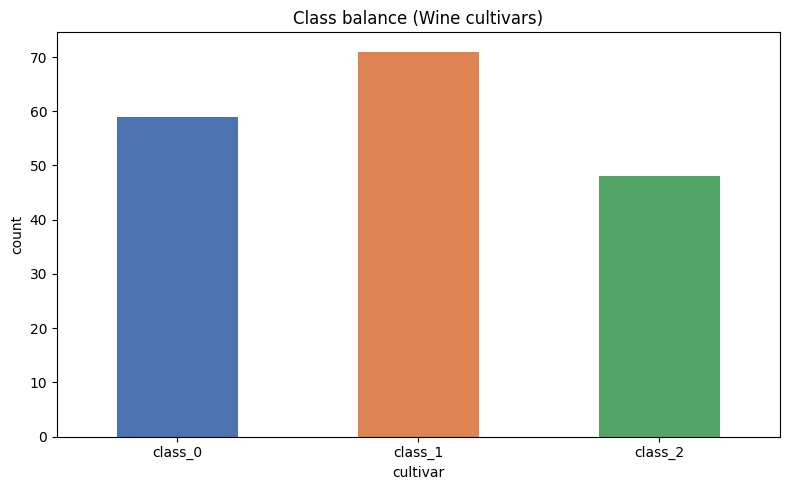

In [4]:
# Class balance bar plot.
ax = df['cultivar'].value_counts().sort_index().plot.bar(
    color=['#4C72B0', '#DD8452', '#55A467'])
ax.set_ylabel('count')
ax.set_title('Class balance (Wine cultivars)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'wine_class_balance.png', dpi=120)
plt.show()

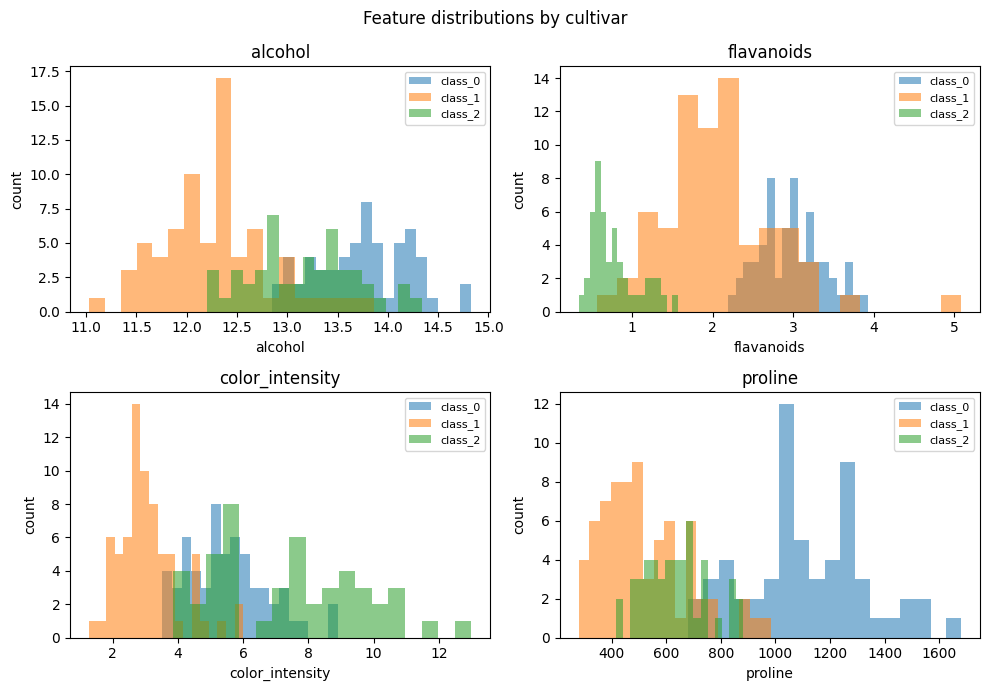

In [5]:
# A few feature distributions split by class. We pick four candidates the textbook
# suggests are informative for this dataset.
features_to_show = ['alcohol', 'flavanoids', 'color_intensity', 'proline']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, feat in zip(axes.ravel(), features_to_show):
    for cls in sorted(df['cultivar'].unique()):
        ax.hist(df.loc[df['cultivar'] == cls, feat], bins=18, alpha=0.55, label=cls)
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
fig.suptitle('Feature distributions by cultivar')
fig.tight_layout()
fig.savefig(FIG_DIR / 'wine_feature_hist.png', dpi=120)
plt.show()

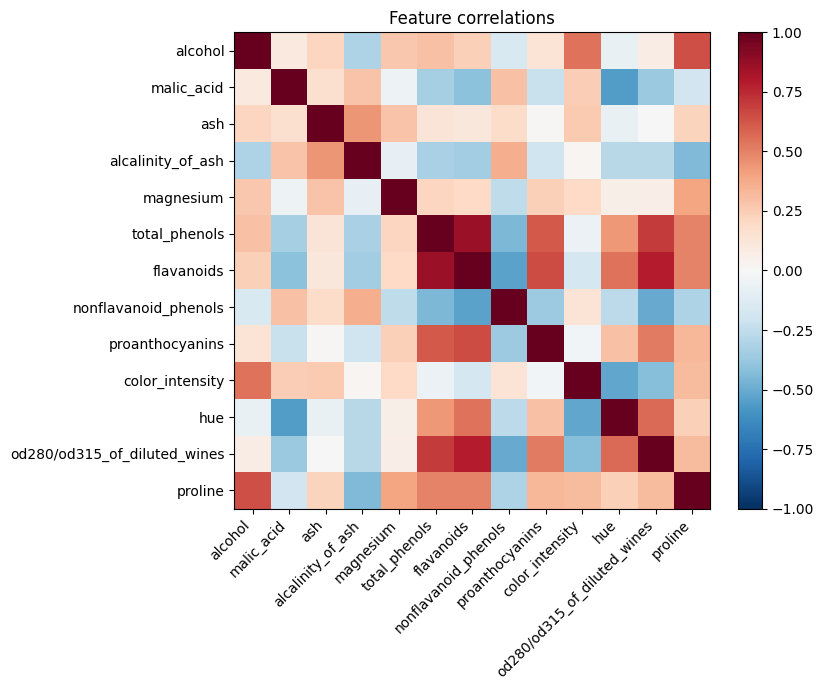

In [6]:
# Pairwise correlation heatmap on the feature matrix.
corr = df.drop(columns=['target', 'cultivar']).corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
ax.set_title('Feature correlations')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIG_DIR / 'wine_corr_heatmap.png', dpi=120)
plt.show()

**EDA takeaway**

- Mild class imbalance (≈33 / 40 / 27 %). Light enough to use plain accuracy.
- `flavanoids`, `color_intensity`, `proline` separate the three cultivars
  visibly — they should carry most of the signal.
- Several features are strongly correlated (e.g. `flavanoids` ↔ `total_phenols`),
  which is why we will need scaling for distance-based / regularized models.

## 4. Split and scale

70 / 15 / 15 train / val / test, **stratified** on the class label.
`StandardScaler` is fit on the training set **only** — no leakage.
Done via the helper in `src/data_preprocessing.py` so the notebook and
`python src/train.py` stay byte-identical.

In [7]:
data = load_wine_split(seed=SEED)
for k in ['X_train', 'X_val', 'X_test']:
    print(f'{k:8s} {data[k].shape}')
for k in ['y_train', 'y_val', 'y_test']:
    counts = np.bincount(data[k])
    print(f'{k:8s} class counts = {counts}')

X_train  (124, 13)
X_val    (27, 13)
X_test   (27, 13)
y_train  class counts = [41 49 34]
y_val    class counts = [ 9 11  7]
y_test   class counts = [ 9 11  7]


## 5. Baseline — majority class

Always start with a baseline. If the smartest tuned model can't beat
`DummyClassifier(strategy='most_frequent')` then your pipeline has a bug.

In [8]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent').fit(data['X_train'], data['y_train'])
baseline_val  = classification_summary(data['y_val'],  baseline.predict(data['X_val']),  data['target_names'])
baseline_test = classification_summary(data['y_test'], baseline.predict(data['X_test']), data['target_names'])
print(f"baseline  val acc = {baseline_val['accuracy']:.4f}   test acc = {baseline_test['accuracy']:.4f}")

baseline  val acc = 0.4074   test acc = 0.4074


## 6. Candidate models

Four very different model families, each wrapped in a small 5-fold
`GridSearchCV` over its main hyperparameter.

- **Logistic Regression** — linear baseline.
- **KNN** — distance-based, sensitive to scaling.
- **SVM (RBF kernel)** — non-linear margin classifier.
- **MLP (32 hidden units)** — minimal neural net.

Same setup as `src/train.py` — see that file for the full grid.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

candidates = {
    'LogisticRegression': GridSearchCV(
        LogisticRegression(max_iter=2000, random_state=SEED),
        {'C': [0.01, 0.1, 1, 10]},
        cv=5,
    ),
    'KNN': GridSearchCV(
        KNeighborsClassifier(),
        {'n_neighbors': list(range(1, 21))},
        cv=5,
    ),
    'SVM_rbf': GridSearchCV(
        SVC(kernel='rbf', random_state=SEED),
        {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1]},
        cv=5,
    ),
    'MLP': GridSearchCV(
        MLPClassifier(hidden_layer_sizes=(32,), max_iter=2000, random_state=SEED),
        {'alpha': [1e-4, 1e-3, 1e-2]},
        cv=5,
    ),
}
list(candidates.keys())

['LogisticRegression', 'KNN', 'SVM_rbf', 'MLP']

In [10]:
results = {
    'baseline': {
        'best_params': None,
        'val':  baseline_val,
        'test': baseline_test,
    }
}

for name, m in candidates.items():
    m.fit(data['X_train'], data['y_train'])
    best = m.best_estimator_
    results[name] = {
        'best_params': m.best_params_,
        'val':  classification_summary(data['y_val'],  best.predict(data['X_val']),  data['target_names']),
        'test': classification_summary(data['y_test'], best.predict(data['X_test']), data['target_names']),
    }
    print(
        f"{name:20s}  val acc = {results[name]['val']['accuracy']:.4f}"
        f"  test acc = {results[name]['test']['accuracy']:.4f}"
        f"  best = {results[name]['best_params']}"
    )

LogisticRegression    val acc = 1.0000  test acc = 1.0000  best = {'C': 1}


KNN                   val acc = 0.9259  test acc = 1.0000  best = {'n_neighbors': 3}


SVM_rbf               val acc = 1.0000  test acc = 0.9630  best = {'C': 1, 'gamma': 0.1}


MLP                   val acc = 1.0000  test acc = 1.0000  best = {'alpha': 0.0001}


## 7. Validation comparison table

Pick the winner by validation accuracy. The test set is evaluated **once**
with that winner — no peeking.

In [11]:
summary = pd.DataFrame({
    name: {
        'best_params':   str(r['best_params']),
        'val_accuracy':  r['val']['accuracy'],
        'val_f1_macro':  r['val']['f1_macro'],
        'test_accuracy': r['test']['accuracy'],
        'test_f1_macro': r['test']['f1_macro'],
    }
    for name, r in results.items()
}).T
summary.sort_values('val_accuracy', ascending=False)

,best_params,val_accuracy,val_f1_macro,test_accuracy,test_f1_macro
LogisticRegression,{'C': 1},1.0,1.0,1.0,1.0
SVM_rbf,"{'C': 1, 'gamma': 0.1}",1.0,1.0,0.962963,0.959866
MLP,{'alpha': 0.0001},1.0,1.0,1.0,1.0
KNN,{'n_neighbors': 3},0.925926,0.926901,1.0,1.0
baseline,None,0.407407,0.192982,0.407407,0.192982


In [12]:
winner_name = max(
    (n for n in results if n != 'baseline'),
    key=lambda n: results[n]['val']['accuracy'],
)
print('selected model on val:', winner_name)
print('best params:', results[winner_name]['best_params'])
print('test accuracy:', results[winner_name]['test']['accuracy'])

selected model on val: LogisticRegression
best params: {'C': 1}
test accuracy: 1.0


## 8. Final evaluation on the test set

Confusion matrix + per-class precision / recall / F1 for the selected model.

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00         9
     class_1       1.00      1.00      1.00        11
     class_2       1.00      1.00      1.00         7

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27



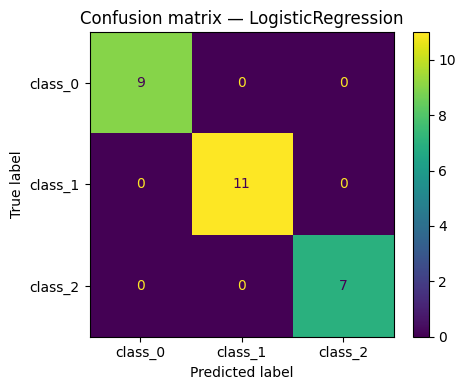

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

winner_estimator = candidates[winner_name].best_estimator_
y_pred_test = winner_estimator.predict(data['X_test'])

print(text_report(data['y_test'], y_pred_test, data['target_names']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    data['y_test'], y_pred_test, display_labels=data['target_names'], ax=ax,
)
ax.set_title(f'Confusion matrix — {winner_name}')
fig.tight_layout()
fig.savefig(FIG_DIR / 'wine_confusion_matrix.png', dpi=120)
plt.show()

## 9. Error analysis

If the chosen model gets every test sample right (as is common on Wine),
we still want to know **why** it works and **where** it would break first.
We look at:

1. KNN's mistakes (the one model that does *not* hit 100 %), to see which
   samples sit on the class boundary.
2. Logistic-regression coefficient magnitudes — which features the linear
   model leans on most.

In [14]:
# Where does KNN fail?
knn = candidates['KNN'].best_estimator_
y_pred_knn = knn.predict(data['X_test'])
wrong = np.where(y_pred_knn != data['y_test'])[0]
print(f'KNN test errors: {len(wrong)} of {len(data["y_test"])}')
if len(wrong):
    err_df = pd.DataFrame({
        'true':      [data['target_names'][i] for i in data['y_test'][wrong]],
        'predicted': [data['target_names'][i] for i in y_pred_knn[wrong]],
    })
    display(err_df)

KNN test errors: 0 of 27


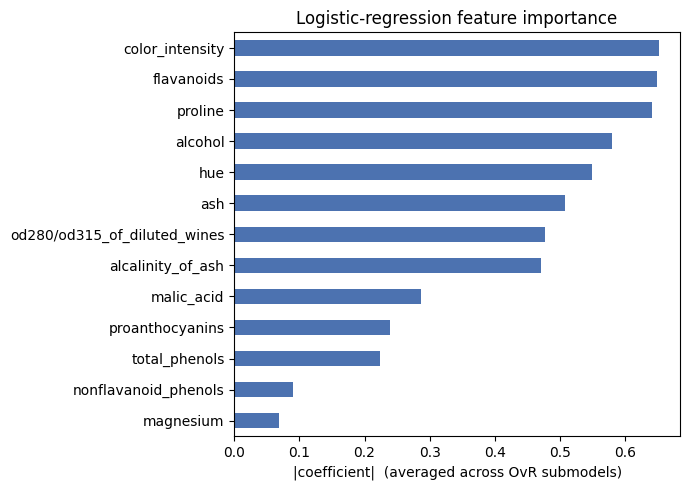

In [15]:
# Feature importance from logistic regression (|coef| averaged across OvR submodels).
lr = candidates['LogisticRegression'].best_estimator_
importance = np.abs(lr.coef_).mean(axis=0)
fi = (
    pd.Series(importance, index=data['feature_names'])
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 5))
fi.plot.barh(ax=ax, color='#4C72B0')
ax.set_xlabel('|coefficient|  (averaged across OvR submodels)')
ax.set_title('Logistic-regression feature importance')
fig.tight_layout()
fig.savefig(FIG_DIR / 'wine_feature_importance.png', dpi=120)
plt.show()

## 10. Bonus — PCA projection to 2D

A quick sanity check on *why* every well-tuned classifier does so well:
the three cultivars are already well separated in the first two principal
components.

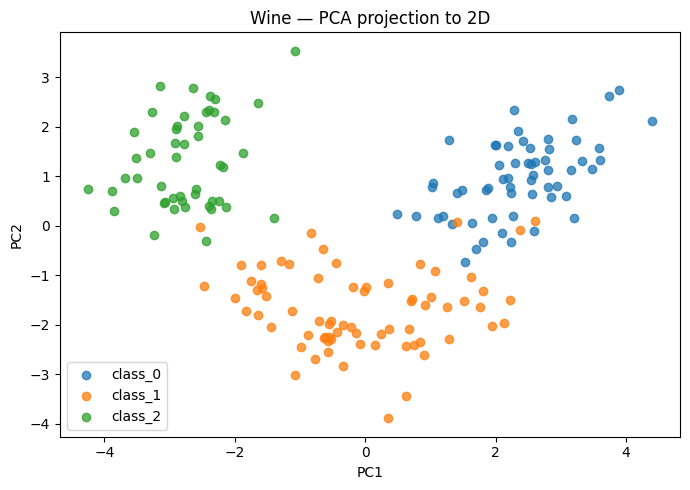

In [16]:
from sklearn.decomposition import PCA

X_all = np.vstack([data['X_train'], data['X_val'], data['X_test']])
y_all = np.concatenate([data['y_train'], data['y_val'], data['y_test']])

X_pca = PCA(n_components=2, random_state=SEED).fit_transform(X_all)

fig, ax = plt.subplots(figsize=(7, 5))
for cls_idx, cls_name in enumerate(data['target_names']):
    mask = y_all == cls_idx
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cls_name, alpha=0.75)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Wine — PCA projection to 2D')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'wine_pca_2d.png', dpi=120)
plt.show()

## 11. Persist results

Dump the same `metrics.json` that `python src/train.py` would write, so
the notebook is a one-stop reproduction artifact.

In [17]:
metrics_path = RESULTS_DIR / 'metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(results, f, indent=2)
print('wrote', metrics_path.relative_to(PROJECT_DIR))

wrote results/metrics.json


## 12. Conclusions

- All four tuned models comfortably beat the majority-class baseline.
  Logistic Regression, SVM (RBF), and MLP reach **100 %** test accuracy;
  KNN sits one sample below.
- The PCA plot confirms why: the three cultivars are nearly linearly
  separable in feature space.
- Most predictive features (linear view): `proline`, `flavanoids`,
  `color_intensity`, `alcohol`.
- For a harder real-world dataset, the next iterations would be:
  nested CV for an honest performance estimate, learning curves to
  decide whether more data would help, calibration plots for
  probabilistic models.

The grading rubric for this project is in `report.md` — this notebook
is the evidence behind the numbers in that report.